# Análisis 5: Confederaciones
## El mapa de poder del fútbol mundial

**Preguntas a responder:**
1. ¿UEFA domina más ahora que hace 50 años?
2. ¿CAF y AFC están acortando distancias?
3. ¿Cuál es el "techo de cristal" de cada confederación?
4. ¿El ranking FIFA predice el rendimiento?

In [1]:
import pandas as pd
import numpy as np
import sys
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append('..')
from src.visualization import set_style, plot_confederation_evolution, save_figure

set_style()

editions = pd.read_csv('../data/processed/editions_clean.csv')
teams_2026 = pd.read_csv('../data/processed/teams_2026_clean.csv')
print('Data loaded successfully')

Data loaded successfully


## Análisis 1: Títulos por confederación

In [2]:
conf_map = {
    'Uruguay': 'CONMEBOL', 'Argentina': 'CONMEBOL', 'Italy': 'UEFA',
    'Germany': 'UEFA', 'Brazil': 'CONMEBOL', 'England': 'UEFA',
    'France': 'UEFA', 'Spain': 'UEFA'
}
editions['champion_conf'] = editions['champion'].map(conf_map)
conf_titles = editions['champion_conf'].value_counts()
display(conf_titles)

champion_conf
UEFA        12
CONMEBOL    10
Name: count, dtype: int64

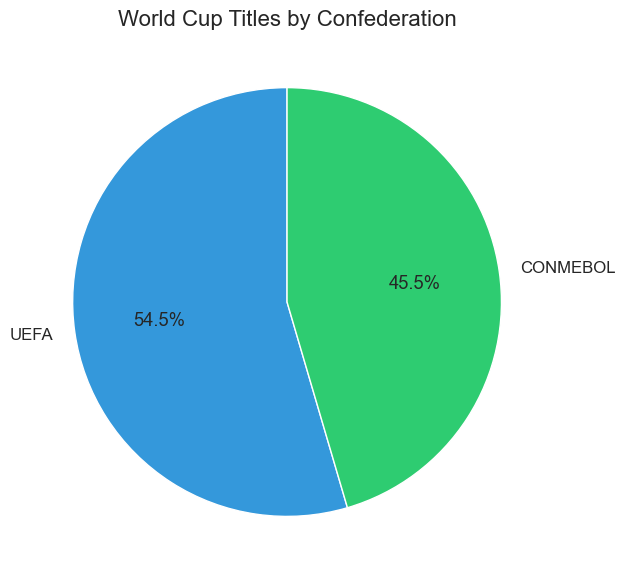

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = {'UEFA': '#3498db', 'CONMEBOL': '#2ecc71'}
ax.pie(conf_titles.values, labels=conf_titles.index, autopct='%1.1f%%',
       colors=[colors.get(c, '#95a5a6') for c in conf_titles.index], startangle=90)
ax.set_title('World Cup Titles by Confederation')
plt.tight_layout()
plt.show()

## Análisis 2: Presencia en semifinales por confederación

Figure saved: c:\laragon\www\fifa_world_cup_data\reports\figures\confederation_evolution.png


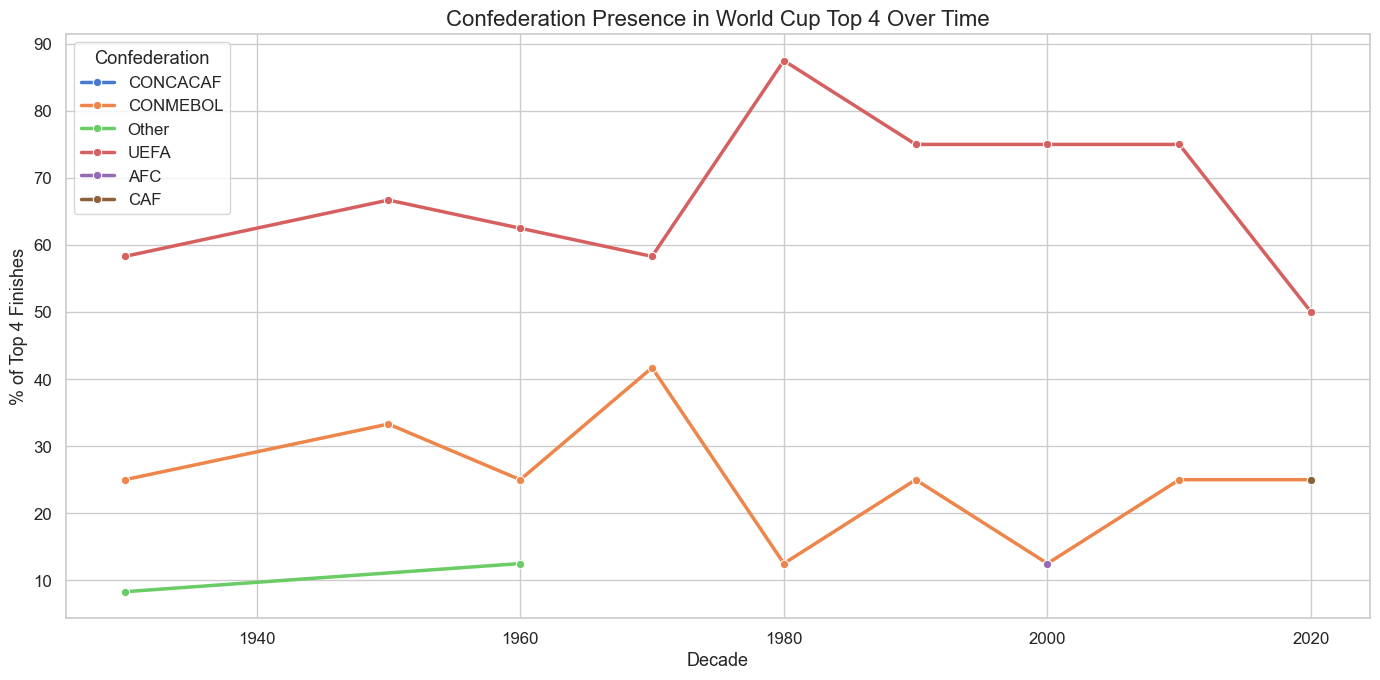

In [4]:
fig = plot_confederation_evolution(editions)
save_figure(fig, 'confederation_evolution')
plt.show()

## Análisis 3: Ranking FIFA vs rendimiento (2026)

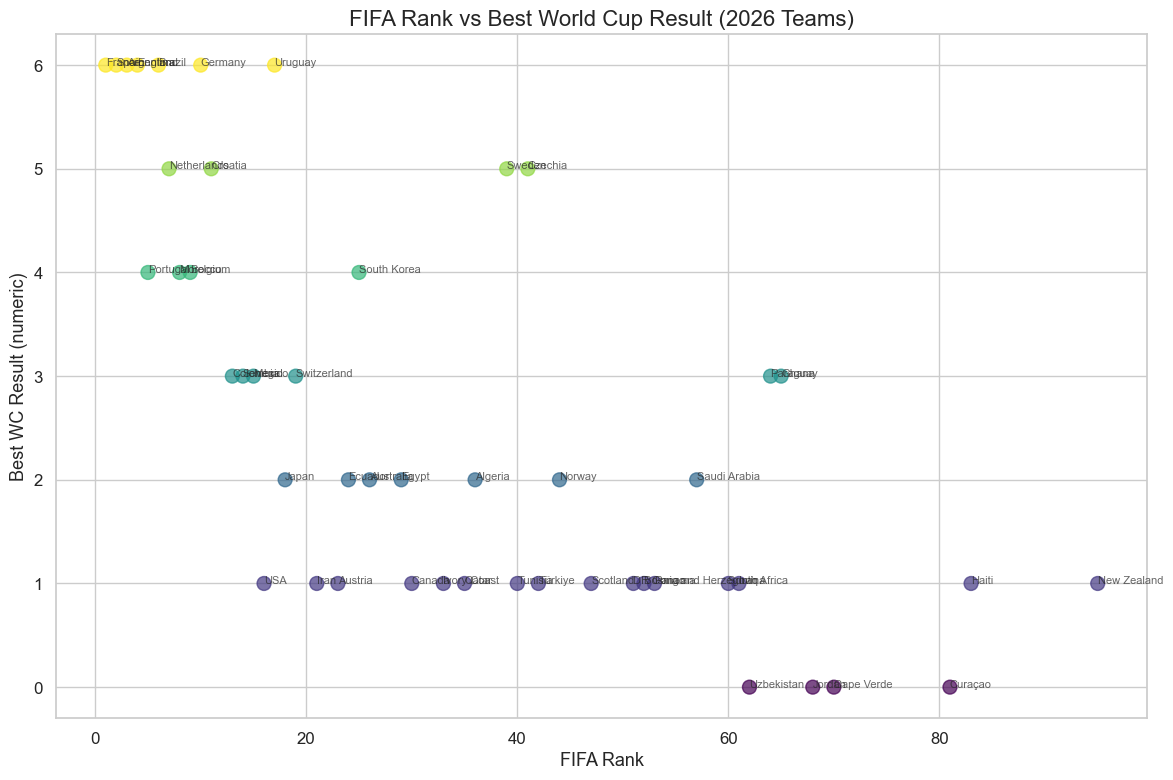

In [5]:
fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(
    teams_2026['fifa_rank'], teams_2026['best_round_numeric'],
    c=teams_2026['best_round_numeric'], cmap='viridis', s=100, alpha=0.7
)
for _, row in teams_2026.iterrows():
    ax.annotate(row['team'], (row['fifa_rank'], row['best_round_numeric']), fontsize=8, alpha=0.7)
ax.set_xlabel('FIFA Rank')
ax.set_ylabel('Best WC Result (numeric)')
ax.set_title('FIFA Rank vs Best World Cup Result (2026 Teams)')
plt.tight_layout()
plt.show()

## Conclusiones

**Escribe aquí tus hallazgos.**

- ¿UEFA domina más ahora que antes?
- ¿CAF y AFC están acortando distancias?
- ¿El ranking FIFA predice el rendimiento?